In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

master = pd.read_csv(
    "../DATA/CLEANED DATA SETS/master_panel.csv"
)

master.head()

,Country,Year,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
0,Australia,2010,66.426834,775.67,220091.029,8.2,0
1,Australia,2011,68.341060,749.42,223451.837,8.3,0
2,Australia,2012,67.268910,746.99,222415.400,8.3,0
3,Australia,2013,69.426270,726.16,218899.242,9.2,0
4,Australia,2014,69.183320,734.18,225954.139,9.3,0


In [2]:
master.describe()

,Year,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
count,369.000000,369.000000,369.000000,3.690000e+02,369.000000,369.000000
mean,2015.558266,60.236930,324.294607,2.906790e+05,24.218970,0.504065
std,3.455068,22.212461,209.922046,6.975428e+05,16.658624,0.500662
min,2010.000000,13.976612,25.920000,6.119861e+03,3.200000,0.000000
25%,2013.000000,40.649040,169.990000,3.897570e+04,11.600000,0.000000
50%,2016.000000,62.096140,296.920000,8.224175e+04,20.600000,1.000000
75%,2019.000000,75.334010,493.070000,2.481987e+05,31.300000,1.000000
max,2021.000000,144.203830,893.030000,4.042840e+06,82.900000,1.000000


In [3]:
corr = master.corr(numeric_only=True)
corr

,Year,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
Year,1.000000,0.069321,-0.175707,-0.004766,0.126855,0.169913
Labour_Productivity,0.069321,1.000000,-0.395833,0.147580,0.178288,0.040157
Carbon_Intensity,-0.175707,-0.395833,1.000000,0.202100,-0.596476,-0.198611
Electricity_Consumption,-0.004766,0.147580,0.202100,1.000000,-0.270951,-0.162107
Renewable_Share,0.126855,0.178288,-0.596476,-0.270951,1.000000,0.418758
Carbon_Tax,0.169913,0.040157,-0.198611,-0.162107,0.418758,1.000000


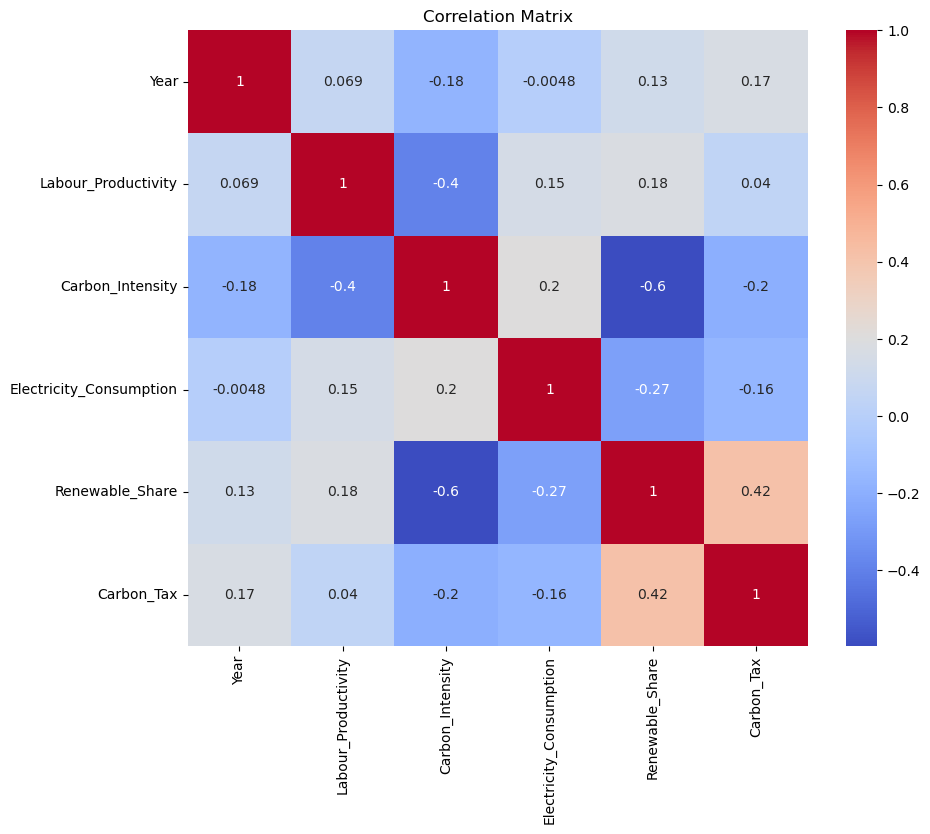

In [4]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

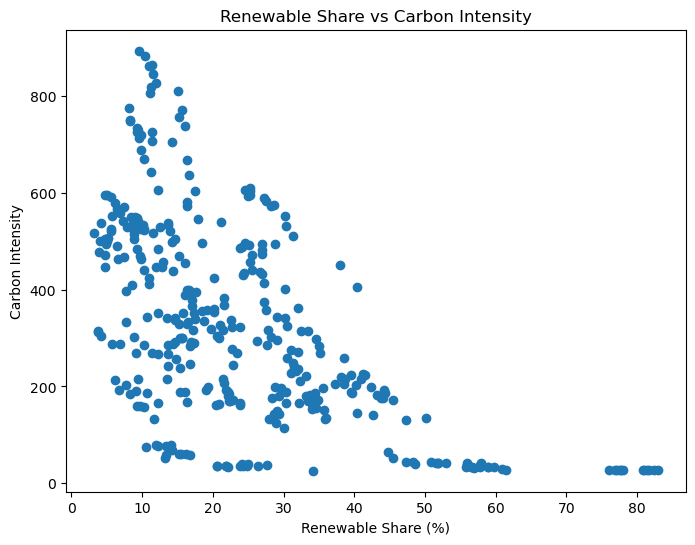

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    master["Renewable_Share"],
    master["Carbon_Intensity"]
)

plt.xlabel("Renewable Share (%)")
plt.ylabel("Carbon Intensity")

plt.title("Renewable Share vs Carbon Intensity")

plt.show()

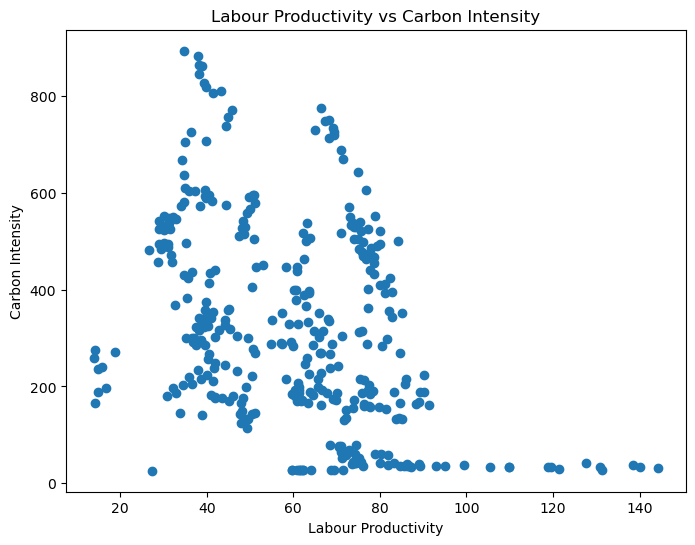

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    master["Labour_Productivity"],
    master["Carbon_Intensity"]
)

plt.xlabel("Labour Productivity")
plt.ylabel("Carbon Intensity")

plt.title("Labour Productivity vs Carbon Intensity")

plt.show()

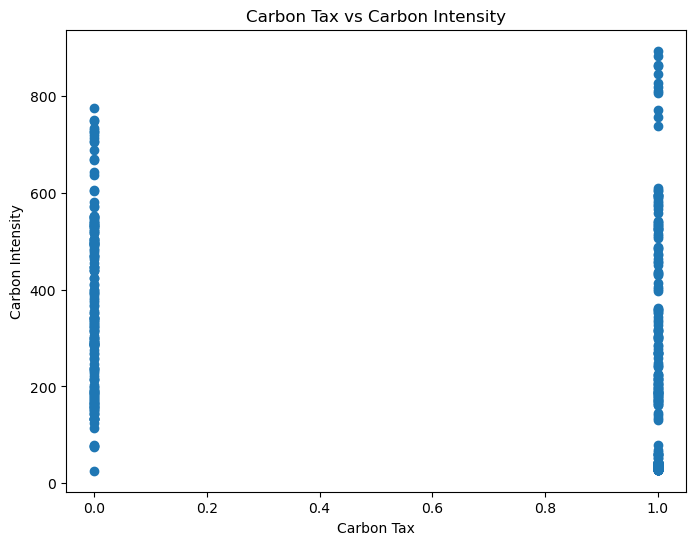

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    master["Carbon_Tax"],
    master["Carbon_Intensity"]
)

plt.xlabel("Carbon Tax")
plt.ylabel("Carbon Intensity")

plt.title("Carbon Tax vs Carbon Intensity")

plt.show()

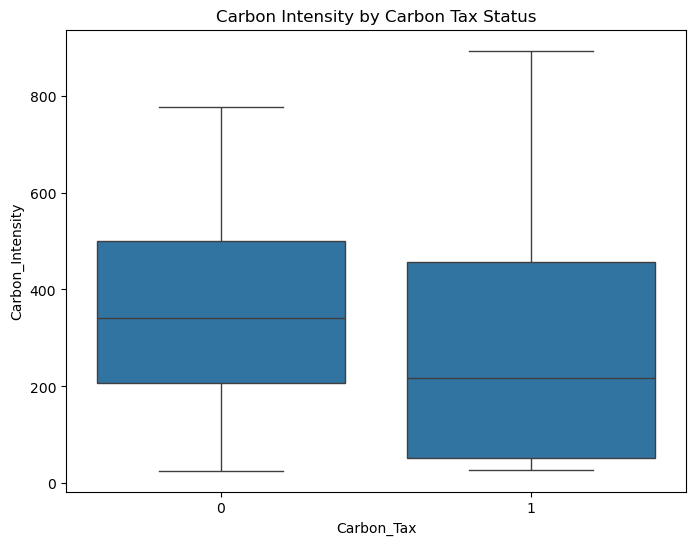

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Carbon_Tax",
    y="Carbon_Intensity",
    data=master
)

plt.title("Carbon Intensity by Carbon Tax Status")

plt.show()

Regression Analysis

1. Is renewable energy associated with lower carbon intensity?

In [9]:
import statsmodels.api as sm

X = master[[
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

y = master["Carbon_Intensity"]

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:       Carbon_Intensity   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     68.74
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.94e-35
Time:                        10:56:14   Log-Likelihood:                -2413.4
No. Observations:                 369   AIC:                             4835.
Df Residuals:                     365   BIC:                             4850.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Interpretation: 

* The model explains about 36.1% of the variation in carbon intensity across countries and years.

* A one percentage-point increase in renewable energy share is associated with approximately a 7.7-unit reduction in carbon intensity, holding electricity consumption and carbon taxes constant.

* Renewable energy adoption is strongly associated with lower carbon intensity. The estimated coefficient is negative and highly significant, suggesting that increasing the renewable share of energy consumption substantially reduces the carbon intensity of electricity generation.

* Electricity consumption does not appear to have a statistically significant independent effect on carbon intensity once renewable energy share and carbon taxes are taken into account.

* It suggests: It's not necessarily how much electricity a country consumes, but how that electricity is produced.

* Carbon taxes do not exhibit a statistically significant direct relationship with carbon intensity after controlling for renewable energy share

In [11]:
import statsmodels.api as sm

X = master[[
    "Carbon_Intensity",
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

y = master["Labour_Productivity"]

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     Labour_Productivity   R-squared:                       0.211
Model:                             OLS   Adj. R-squared:                  0.203
Method:                  Least Squares   F-statistic:                     24.40
Date:                 Fri, 29 May 2026   Prob (F-statistic):           6.57e-18
Time:                         11:31:11   Log-Likelihood:                -1623.4
No. Observations:                  369   AIC:                             3257.
Df Residuals:                      364   BIC:                             3276.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const           

* The model explains about 21.1% of the variation in labour productivity.
* The model as a whole is highly significant.
* Higher carbon intensity is associated with lower labour productivity.
* Countries with cleaner electricity systems tend to exhibit higher labour productivity.
* Higher electricity consumption is associated with higher labour productivity.
* Energy consumption appears positively associated with economic productivity, while carbon intensity appears negatively associated with productivity.
* Once carbon intensity is already in the model, renewable share provides little additional explanatory power for productivity.


* The results suggest that environmental sustainability and economic performance may not be competing objectives. Renewable energy adoption is associated with lower carbon intensity, while lower carbon intensity is associated with higher labour productivity. These findings indicate that cleaner energy systems may support both environmental and economic outcomes.

* Renewable Share → Lower Carbon Intensity
* Lower Carbon Intensity → Higher Productivity
* Electricity Consumption → Higher Productivity

# Fixed Effects Models

Carbon_Intensityit​=β1​Renewable_Shareit​+β2​Electricity_Consumptionit​+β3​Carbon_Taxit​+αi​+ϵit​

In [12]:
pip install linearmodels

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.1 MB/s eta 0:00:00

   -------------------- ------------------- 2/4 [formulaic]
   -------------------- ------------------- 2/4 [formulaic]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ------------------------------ --------- 3/4 [linearmodels]
   ---------------------------------------- 4/4 [linearmodels]

Note: you may need to restart the kernel to use updated packages.


In [13]:
import linearmodels

In [14]:
from linearmodels.panel import PanelOLS

print("linearmodels installed successfully")

linearmodels installed successfully


In [15]:
panel_data = master.set_index(["Country", "Year"])

In [16]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

y = panel_data["Carbon_Intensity"]

X = panel_data[[
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

fe_model1 = PanelOLS(
    y,
    X,
    entity_effects=True
)

fe_results1 = fe_model1.fit()

print(fe_results1)

                          PanelOLS Estimation Summary                           
Dep. Variable:       Carbon_Intensity   R-squared:                        0.5462
Estimator:                   PanelOLS   R-squared (Between):             -0.7851
No. Observations:                 369   R-squared (Within):               0.5462
Date:                Fri, May 29 2026   R-squared (Overall):             -0.7626
Time:                        12:25:48   Log-likelihood                   -1834.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      134.03
Entities:                          32   P-value                           0.0000
Avg Obs:                       11.531   Distribution:                   F(3,334)
Min Obs:                       1.0000                                           
Max Obs:                       12.000   F-statistic (robust):             134.03
                            

* Within a country, a one percentage-point increase in renewable energy share is associated with approximately a 13.2-unit reduction in carbon intensity
* Increases in electricity consumption are associated with slightly lower carbon intensity.
* After controlling for country-specific characteristics, carbon taxes are associated with lower carbon intensity

In [17]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

y = panel_data["Labour_Productivity"]

X = panel_data[[
    "Carbon_Intensity",
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

fe_model2 = PanelOLS(
    y,
    X,
    entity_effects=True
)

fe_results2 = fe_model2.fit()

print(fe_results2)

                           PanelOLS Estimation Summary                           
Dep. Variable:     Labour_Productivity   R-squared:                        0.3059
Estimator:                    PanelOLS   R-squared (Between):             -0.0932
No. Observations:                  369   R-squared (Within):               0.3059
Date:                 Fri, May 29 2026   R-squared (Overall):             -0.0660
Time:                         12:30:18   Log-likelihood                   -983.42
Cov. Estimator:             Unadjusted                                           
                                         F-statistic:                      36.686
Entities:                           32   P-value                           0.0000
Avg Obs:                        11.531   Distribution:                   F(4,333)
Min Obs:                        1.0000                                           
Max Obs:                        12.000   F-statistic (robust):             36.686
                

* Within countries over time, increases in renewable energy share are associated with higher labour productivity
* The negative Carbon Intensity–Productivity relationship we saw earlier appears to be driven mainly by differences between countries rather than changes within countries over time.
  

# Fixed Effects Results

Model 1: Carbon Intensity

Key findings:
* Renewable Share → Lower Carbon Intensity 
* Carbon Tax → Lower Carbon Intensity 
* Electricity Consumption → Slightly Lower Carbon Intensity 

Model 2: Labour Productivity

Key findings:
* Renewable Share → Higher Productivity 
* Carbon Intensity → Not Significant 
* Carbon Tax → Not Significant 
* Electricity Consumption → Not Significant 

# Preliminary Discussion

The fixed-effects results suggest that environmental sustainability and economic productivity may be compatible rather than conflicting objectives.

The strongest finding is that increases in renewable energy share are associated with both lower carbon intensity and higher labour productivity within countries over time. This indicates that countries may be able to reduce the environmental impact of their energy systems while simultaneously maintaining or improving economic performance.

The results also show that carbon taxes are associated with lower carbon intensity, suggesting that environmental policies can contribute to cleaner energy systems. However, carbon taxes do not appear to have a direct effect on labour productivity in the current specification.

Importantly, the findings imply that the key challenge associated with AI infrastructure may not be electricity consumption itself, but rather how that electricity is generated. As AI infrastructure expands and electricity demand increases, countries with cleaner energy systems may be better positioned to obtain the productivity benefits of AI while limiting environmental harm.

Overall, the evidence provides preliminary support for the idea that the environmental costs associated with AI infrastructure can potentially be reconciled with economic productivity gains through renewable energy adoption and sustainable energy transitions.

In [18]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

y = panel_data["Carbon_Intensity"]

X = panel_data[[
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

twfe_model1 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

twfe_results1 = twfe_model1.fit()

print(twfe_results1)

                          PanelOLS Estimation Summary                           
Dep. Variable:       Carbon_Intensity   R-squared:                        0.2489
Estimator:                   PanelOLS   R-squared (Between):             -0.0753
No. Observations:                 369   R-squared (Within):               0.5028
Date:                Fri, May 29 2026   R-squared (Overall):             -0.0594
Time:                        12:49:40   Log-likelihood                   -1812.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      35.687
Entities:                          32   P-value                           0.0000
Avg Obs:                       11.531   Distribution:                   F(3,323)
Min Obs:                       1.0000                                           
Max Obs:                       12.000   F-statistic (robust):             35.687
                            

# Interpretation:
* The apparent carbon-tax effect may have been capturing broader global trends over time rather than a distinct policy effect
* Once we control for both country-specific and year-specific factors, electricity consumption does not appear to have an independent effect on carbon intensity
* Countries that increase their renewable energy share tend to experience significantly lower carbon intensity, even after controlling for country-specific characteristics and common time trends

In [19]:
y = panel_data["Labour_Productivity"]

X = panel_data[[
    "Carbon_Intensity",
    "Renewable_Share",
    "Electricity_Consumption",
    "Carbon_Tax"
]]

X = sm.add_constant(X)

twfe_model2 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

twfe_results2 = twfe_model2.fit()

print(twfe_results2)

                           PanelOLS Estimation Summary                           
Dep. Variable:     Labour_Productivity   R-squared:                        0.0711
Estimator:                    PanelOLS   R-squared (Between):             -0.0273
No. Observations:                  369   R-squared (Within):               0.2195
Date:                 Fri, May 29 2026   R-squared (Overall):             -0.0212
Time:                         12:53:47   Log-likelihood                   -948.47
Cov. Estimator:             Unadjusted                                           
                                         F-statistic:                      6.1601
Entities:                           32   P-value                           0.0001
Avg Obs:                        11.531   Distribution:                   F(4,322)
Min Obs:                        1.0000                                           
Max Obs:                        12.000   F-statistic (robust):             6.1601
                

# Interpretation

Increasing renewable energy share is associated with higher labour productivity.

# Final Empirical Findings

1. Renewable energy share is the most robust determinant of carbon intensity in the sample.

2. Renewable energy share is positively associated with labour productivity.

3. The relationship between renewable energy share and both outcomes remains statistically significant after controlling for both country and year fixed effects.

4. Carbon taxes and electricity consumption do not exhibit robust direct effects in the strongest model specifications.

5. The findings suggest that environmental sustainability and economic productivity may be complementary rather than conflicting objectives.

6. The results provide preliminary evidence that the environmental costs associated with AI infrastructure may potentially be mitigated through renewable energy transitions and cleaner energy systems.

7. Overall, the evidence supports the argument that countries may be able to achieve productivity gains while simultaneously reducing environmental harm through cleaner energy generation and sustainable energy transitions.



In [20]:
master.to_csv(
    "../DATA/CLEANED DATA SETS/master_panel.csv",
    index=False
)

In [21]:
import os

In [22]:
import os

os.listdir("../DATA/CLEANED DATA SETS")

['carbon_intensity.csv',
 'carbon_tax.csv',
 'electricity_consumption.csv',
 'labour_productivity.csv',
 'master_panel.csv',
 'renewable_energy_share.csv']

In [23]:
import os

os.makedirs(
    "../RESULTS",
    exist_ok=True
)

In [24]:
corr.to_csv(
    "../RESULTS/correlation_matrix.csv"
)

In [25]:
os.listdir("../RESULTS")

['correlation_matrix.csv']

In [26]:
with open("../RESULTS/twfe_carbon_intensity.txt", "w") as f:
    f.write(str(twfe_results1))

In [27]:
with open("../RESULTS/twfe_labour_productivity.txt", "w") as f:
    f.write(str(twfe_results2))

In [28]:
plt.savefig(
    "../RESULTS/renewable_vs_carbon.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [29]:
os.makedirs(
    "../FIGURES",
    exist_ok=True
)

In [32]:
os.listdir("../RESULTS")

['correlation_matrix.csv',
 'renewable_vs_carbon.png',
 'twfe_carbon_intensity.txt',
 'twfe_labour_productivity.txt']

# Limitations

1. The analysis does not directly measure AI adoption or generative AI usage.

2. AI is studied through the infrastructure and energy-system lens rather than direct measures of AI activity.

3. Carbon tax is measured as a categorical indicator rather than the monetary value of the tax.

4. The panel covers 32 countries from 2010–2021 and may not capture very recent developments in AI infrastructure.

5. The analysis identifies associations rather than definitive causal relationships.

In [35]:
%whos

Variable               Type                        Data/Info
------------------------------------------------------------
PanelOLS               type                        <class 'linearmodels.panel.model.PanelOLS'>
X                      DataFrame                                       const<...>n\n[369 rows x 5 columns]
corr                   DataFrame                                            <...>   0.418758    1.000000  
dataframe_columns      function                    <function dataframe_colum<...>ns at 0x000001596E5277E0>
dataframe_hash         function                    <function dataframe_hash at 0x000001596E5256C0>
dtypes_str             function                    <function dtypes_str at 0x000001596E525620>
f                      TextIOWrapper               <_io.TextIOWrapper name='<...>de='w' encoding='cp1252'>
fe_model1              PanelOLS                    PanelOLS \nNum exog: 4, C<...>lse, Num Other Effects: 0
fe_model2              PanelOLS                    Pan

In [36]:
print(twfe_results1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       Carbon_Intensity   R-squared:                        0.2489
Estimator:                   PanelOLS   R-squared (Between):             -0.0753
No. Observations:                 369   R-squared (Within):               0.5028
Date:                Fri, May 29 2026   R-squared (Overall):             -0.0594
Time:                        12:49:40   Log-likelihood                   -1812.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      35.687
Entities:                          32   P-value                           0.0000
Avg Obs:                       11.531   Distribution:                   F(3,323)
Min Obs:                       1.0000                                           
Max Obs:                       12.000   F-statistic (robust):             35.687
                            

In [37]:
print(twfe_results2.summary)

                           PanelOLS Estimation Summary                           
Dep. Variable:     Labour_Productivity   R-squared:                        0.0711
Estimator:                    PanelOLS   R-squared (Between):             -0.0273
No. Observations:                  369   R-squared (Within):               0.2195
Date:                 Fri, May 29 2026   R-squared (Overall):             -0.0212
Time:                         12:53:47   Log-likelihood                   -948.47
Cov. Estimator:             Unadjusted                                           
                                         F-statistic:                      6.1601
Entities:                           32   P-value                           0.0001
Avg Obs:                        11.531   Distribution:                   F(4,322)
Min Obs:                        1.0000                                           
Max Obs:                        12.000   F-statistic (robust):             6.1601
                

In [14]:
%who

corr_vars	 csv_files	 dataframe_columns	 dataframe_hash	 dtypes_str	 get_dataframes	 getpass	 hashlib	 import_pandas_safely	 
is_data_frame	 json	 os	 pd	 plt	 sns	 


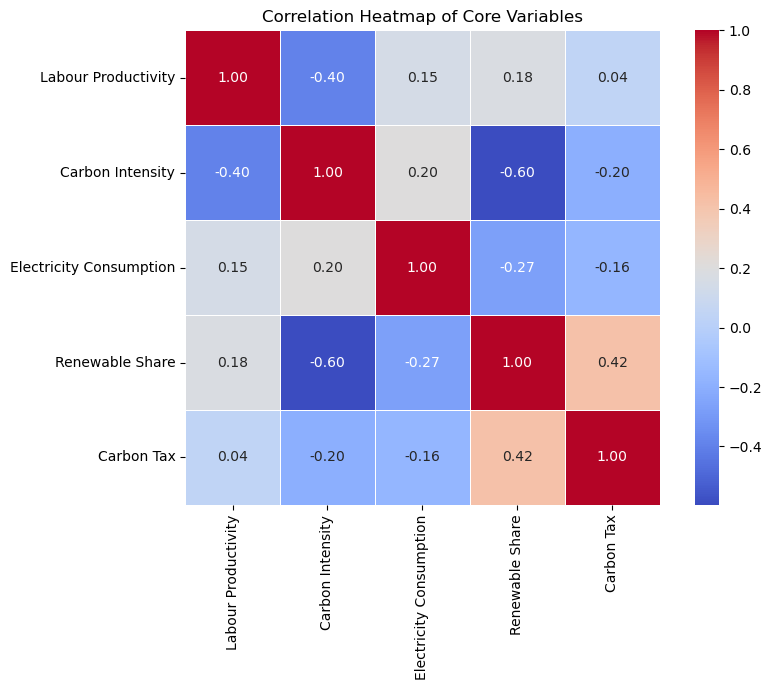

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = [
    'Labour_Productivity',
    'Carbon_Intensity',
    'Electricity_Consumption',
    'Renewable_Share',
    'Carbon_Tax'
]

corr_dissertation = data[corr_vars].corr()

# Rename variables for presentation
corr_dissertation.columns = [
    'Labour Productivity',
    'Carbon Intensity',
    'Electricity Consumption',
    'Renewable Share',
    'Carbon Tax'
]

corr_dissertation.index = [
    'Labour Productivity',
    'Carbon Intensity',
    'Electricity Consumption',
    'Renewable Share',
    'Carbon Tax'
]

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_dissertation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Core Variables")

plt.tight_layout()

plt.savefig(
    "Figure_6_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

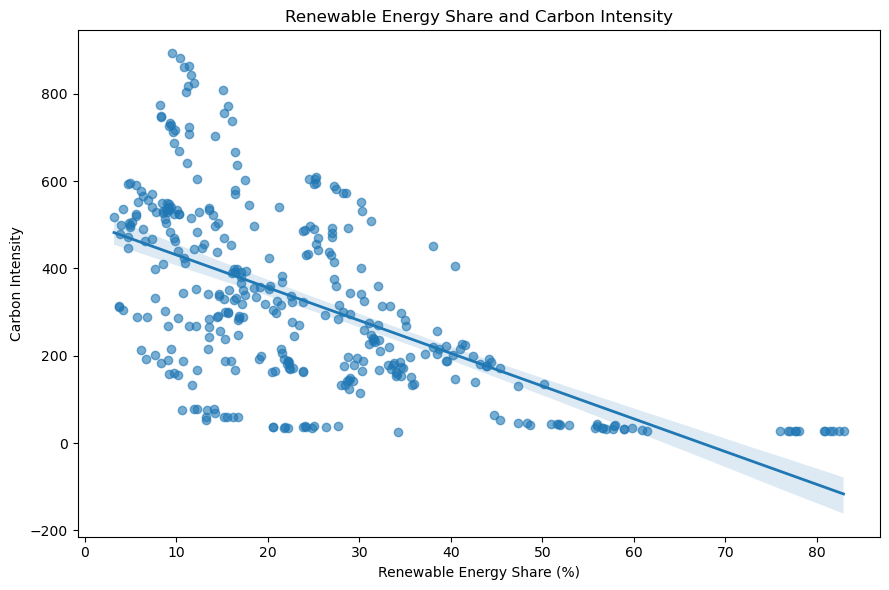

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

sns.regplot(
    data=data,
    x="Renewable_Share",
    y="Carbon_Intensity",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2},
    ci=95
)

plt.title("Renewable Energy Share and Carbon Intensity")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Carbon Intensity")

plt.tight_layout()

plt.savefig(
    "Figure_7_Renewable_Share_vs_Carbon_Intensity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

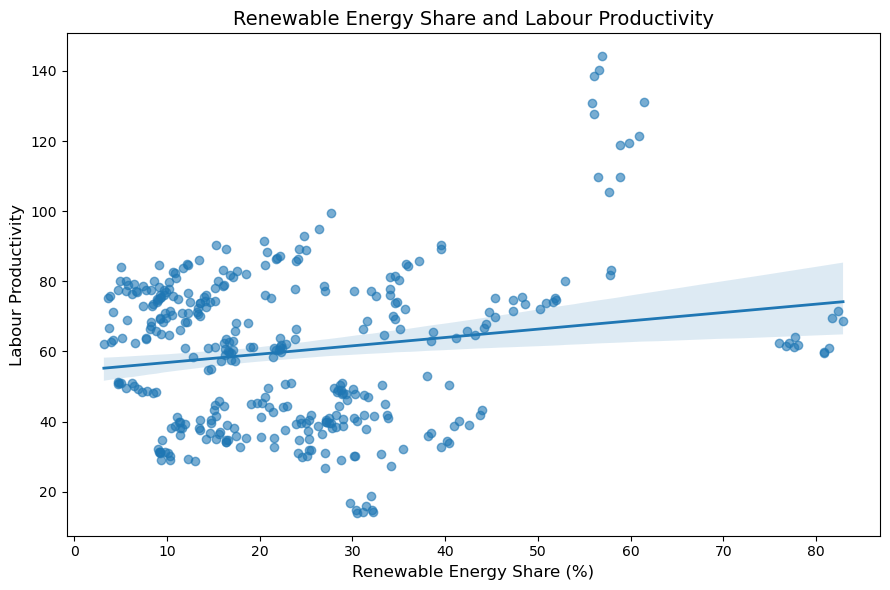

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

sns.regplot(
    data=data,
    x='Renewable_Share',
    y='Labour_Productivity',
    scatter_kws={'alpha':0.6},
    line_kws={'linewidth':2},
    ci=95
)

plt.title(
    'Renewable Energy Share and Labour Productivity',
    fontsize=14
)

plt.xlabel(
    'Renewable Energy Share (%)',
    fontsize=12
)

plt.ylabel(
    'Labour Productivity',
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    'Figure_8_Renewable_Share_vs_Labour_Productivity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

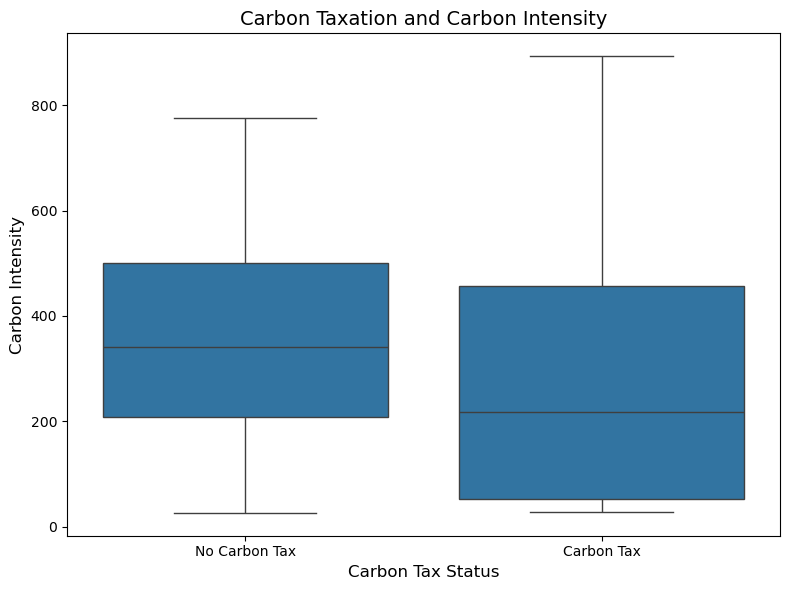

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=data,
    x='Carbon_Tax',
    y='Carbon_Intensity'
)

plt.title(
    'Carbon Taxation and Carbon Intensity',
    fontsize=14
)

plt.xlabel(
    'Carbon Tax Status',
    fontsize=12
)

plt.ylabel(
    'Carbon Intensity',
    fontsize=12
)

# Replace 0 and 1 with meaningful labels
plt.xticks(
    [0, 1],
    ['No Carbon Tax', 'Carbon Tax']
)

plt.tight_layout()

plt.savefig(
    'Figure_9_Carbon_Taxation_Boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

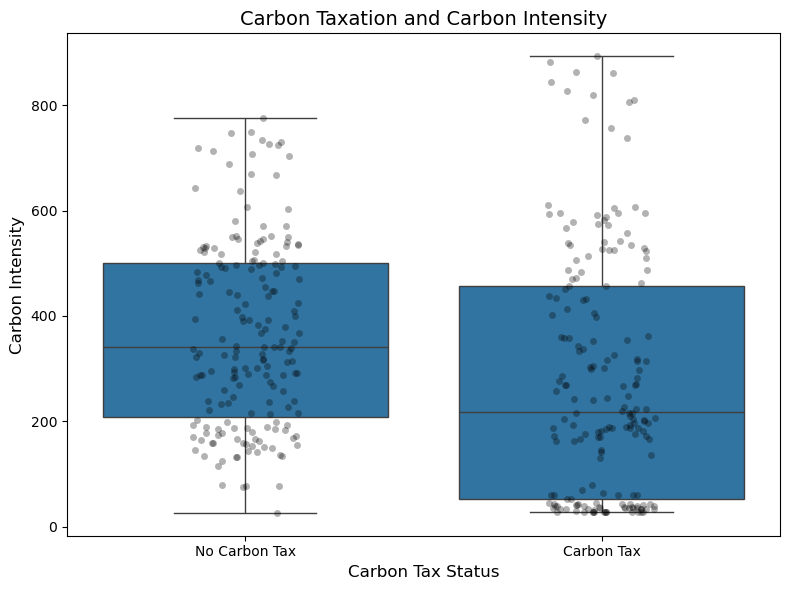

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=data,
    x='Carbon_Tax',
    y='Carbon_Intensity'
)

sns.stripplot(
    data=data,
    x='Carbon_Tax',
    y='Carbon_Intensity',
    color='black',
    alpha=0.3,
    jitter=0.15
)

plt.title(
    'Carbon Taxation and Carbon Intensity',
    fontsize=14
)

plt.xlabel(
    'Carbon Tax Status',
    fontsize=12
)

plt.ylabel(
    'Carbon Intensity',
    fontsize=12
)

plt.xticks(
    [0, 1],
    ['No Carbon Tax', 'Carbon Tax']
)

plt.tight_layout()

plt.savefig(
    'Figure_9_Carbon_Taxation_Boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()